# Waltham Forest UPRN energy comparison

This notebook:
- loads your half-hourly electric + gas data for UPRN `100022558916`
- runs the ABM for the UPRN's LSOA over the same time window
- compares actual vs simulated hourly and monthly kWh


In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path

from household_energy.model import EnergyModel
from household_energy.climate import ClimateField


In [2]:
# ---- Paths & constants ----
DATA_DIR = Path("../data").resolve()

EPC_GEOJSON = DATA_DIR / "epc_abm_waltham_forest.geojson"
HIDP_CSV = DATA_DIR / "wf_hidp_uprn_matches_tiered.csv"
CLIMATE_PARQUET = DATA_DIR / "waltham_forest_2t_timeseries_2010_2026.parquet"

ELECTRIC_CSV = DATA_DIR / "wf_electricity data.csv"
GAS_CSV = DATA_DIR / "wf_gas data.csv"

TARGET_UPRN = "100022558916"
LOCAL_TZ = "Europe/London"

CONFIG_PATH = Path("../configs/wf_uprn_tuning.yaml").resolve()


In [3]:
# ---- Run scope ----
# If True, simulate only the target UPRN (fast, but no LSOA peers)
RUN_ONLY_TARGET = True


In [4]:
# ---- Load actual half-hourly data ----

def _load_halfhourly(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df["Start"] = pd.to_datetime(df["Start"], utc=True)
    df["End"] = pd.to_datetime(df["End"], utc=True)
    df = df.rename(columns={"Consumption (kwh)": "kwh"})
    return df[["Start", "End", "kwh"]].copy()

el_df = _load_halfhourly(ELECTRIC_CSV)
ng_df = _load_halfhourly(GAS_CSV)

# Define analysis window from the union of electric+gas time spans
start_ts = min(el_df["Start"].min(), ng_df["Start"].min())
end_ts = max(el_df["End"].max(), ng_df["End"].max())

start_ts, end_ts


(Timestamp('2025-04-30 23:00:00+0000', tz='UTC'),
 Timestamp('2026-01-29 00:00:00+0000', tz='UTC'))

In [5]:
# ---- Downsample to hourly (sum of 2 half-hour slots) ----

def _to_hourly(df: pd.DataFrame, label: str) -> pd.DataFrame:
    out = df.copy()
    out["hour"] = out["Start"].dt.floor("H")
    out = out.groupby("hour", as_index=False)["kwh"].sum()
    out = out.rename(columns={"kwh": label})
    return out

el_hr = _to_hourly(el_df, "electric_kwh")
ng_hr = _to_hourly(ng_df, "gas_kwh")

# Align on a full hourly index for the window
hour_index = pd.date_range(start_ts.floor("H"), end_ts.floor("H"), freq="H", tz="UTC", inclusive="left")
actual = pd.DataFrame({"timestamp": hour_index})
actual = actual.merge(el_hr, left_on="timestamp", right_on="hour", how="left").drop(columns=["hour"])
actual = actual.merge(ng_hr, left_on="timestamp", right_on="hour", how="left").drop(columns=["hour"])
actual[["electric_kwh", "gas_kwh"]] = actual[["electric_kwh", "gas_kwh"]].fillna(0.0)
actual["actual_total_kwh"] = actual["electric_kwh"] + actual["gas_kwh"]

actual.head()


/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/2567526152.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  out["hour"] = out["Start"].dt.floor("H")
/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/2567526152.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  out["hour"] = out["Start"].dt.floor("H")
/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/2567526152.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hour_index = pd.date_range(start_ts.floor("H"), end_ts.floor("H"), freq="H", tz="UTC", inclusive="left")


,timestamp,electric_kwh,gas_kwh,actual_total_kwh
0,2025-04-30 23:00:00+00:00,0.005,0.0,0.005
1,2025-05-01 00:00:00+00:00,0.006,0.0,0.006
2,2025-05-01 01:00:00+00:00,0.005,0.0,0.005
3,2025-05-01 02:00:00+00:00,0.005,0.0,0.005
4,2025-05-01 03:00:00+00:00,0.005,0.0,0.005


In [6]:
# ---- Load EPC geojson, find target LSOA, and subset ----

gdf_all = gpd.read_file(EPC_GEOJSON)

# Find the target UPRN and its LSOA
row = gdf_all[gdf_all["UPRN"].astype(str) == TARGET_UPRN]
if row.empty:
    raise ValueError(f"UPRN {TARGET_UPRN} not found in EPC geojson")

lsoa_code = row.iloc[0]["lsoa_code"]
print("Target LSOA:", lsoa_code)

# Filter to that LSOA (or only the target UPRN if requested)
if RUN_ONLY_TARGET:
    lsoa_gdf = row.copy()
    print("Running only target UPRN for speed. Homes:", len(lsoa_gdf))
else:
    lsoa_gdf = gdf_all[gdf_all["lsoa_code"] == lsoa_code].copy()
    print("Homes in LSOA:", len(lsoa_gdf))


Target LSOA: E01034485
Running only target UPRN for speed. Homes: 1


In [7]:
# ---- Join HIDP (optional but useful for schedules/household sizes) ----

hidp_df = pd.read_csv(HIDP_CSV, low_memory=False)

# Normalize join keys to string
lsoa_gdf["UPRN"] = lsoa_gdf["UPRN"].astype(str).str.strip()
hidp_df["uprn_chr"] = hidp_df["uprn_chr"].astype(str).str.strip()

lsoa_gdf = lsoa_gdf.merge(
    hidp_df,
    how="left",
    left_on="UPRN",
    right_on="uprn_chr",
    suffixes=("_geo", "_hidp"),
)

lsoa_gdf.head(2)


,UPRN,lsoa_code_geo,local_authority,ward_code,habitable_rooms,sap_rating,floor_area_m2,property_type,property_age,main_fuel_type,...,dwelling_bucket,tenure,size_band,hidp,hh_n_people,hh_children,hh_income,hh_income_band,schedule_type,hh_edu_detail
0,100022558916,E01034485,E09000031,E05013902,4.0,70,70.0,mid-terraced house,1930-1949,mains gas,...,terraced_house,private_rent,4,1.500645e+09,5.0,True,188.0,q1_lowest,working_adult_household,postgrad_or_degree


In [8]:
# ---- Run the model for the same time window ----

# Align to climate grid to avoid off-by-one issues
cf = ClimateField(str(CLIMATE_PARQUET))
i0 = cf.time_index_for(start_ts)
i1 = cf.time_index_for(end_ts)
if i1 <= i0:
    raise ValueError("Window invalid for this climate file (end <= start).")

num_hours = int(i1 - i0)
start_utc_aligned = pd.to_datetime(cf.times[i0], utc=True)
end_utc_aligned = start_utc_aligned + pd.to_timedelta(num_hours, unit="h")

print(f"Aligned window: {start_utc_aligned} → {end_utc_aligned} (exclusive)")
print("Simulated hours:", num_hours)

model = EnergyModel(
    gdf=lsoa_gdf,
    climate_parquet=str(CLIMATE_PARQUET),
    climate_start=start_utc_aligned,  # tz-aware UTC
    local_tz=LOCAL_TZ,
    config_path=str(CONFIG_PATH),
    collect_agent_level=True,
    agent_collect_every=1,
)

for _ in range(num_hours):
    model.step()


Aligned window: 2025-04-30 23:00:00+00:00 → 2026-01-29 00:00:00+00:00 (exclusive)
Simulated hours: 6553


In [9]:
# ---- Extract simulated hourly series for target UPRN ----

agent_df = model.agent_dc.get_agent_vars_dataframe().reset_index()

# Mesa DataCollector typically exposes columns: Step, AgentID, ...
if "AgentID" not in agent_df.columns:
    raise ValueError("Expected AgentID column in agent_df")

# Validate new columns exist
needed = ["electric_kwh", "gas_kwh", "other_kwh", "base_kwh", "heat_kwh", "spike_kwh", "climate_cooling_kWh"]
missing_cols = [c for c in needed if c not in agent_df.columns]
if missing_cols:
    raise KeyError(
        "Missing columns: " + ", ".join(missing_cols) +
        ". Restart kernel after code changes and re-run the model cell."
    )

# Ensure multipliers exist (use defaults if cell not run)
if "MODEL_ELECTRIC_HEAT_MULT" not in globals():
    MODEL_ELECTRIC_HEAT_MULT = 1.0
if "MODEL_GAS_HEAT_MULT" not in globals():
    MODEL_GAS_HEAT_MULT = 1.0
if "SPIKE_MULT" not in globals():
    SPIKE_MULT = 1.0
if "GAS_SPIKE_SHARE" not in globals():
    GAS_SPIKE_SHARE = 0.3

hh = agent_df[(agent_df["agent_type"] == "household") & (agent_df["AgentID"].astype(str) == TARGET_UPRN)].copy()

# Map Step to timestamps (UTC) aligned with climate grid
hh["timestamp"] = start_utc_aligned + pd.to_timedelta(hh["Step"], unit="h")

sim = hh[[
    "timestamp", "energy_consumption", "electric_kwh", "gas_kwh", "other_kwh",
    "base_kwh", "heat_kwh", "spike_kwh", "climate_cooling_kWh",
    "is_gas", "is_electric_heating", "main_fuel_type", "main_heating_system",
]].rename(columns={"energy_consumption": "model_total_kwh"})

# Apply optional spike multiplier for schedule intensity
sim["spike_kwh"] = sim["spike_kwh"] * SPIKE_MULT

# Determine heating fuel bucket for this home
fuel = (sim["main_fuel_type"].iloc[0] or "").lower() if len(sim) else ""
heat = (sim["main_heating_system"].iloc[0] or "").lower() if len(sim) else ""
if (sim["is_electric_heating"].iloc[0] if len(sim) else 0) == 1 or "electric" in fuel:
    heating_fuel = "electric"
elif (sim["is_gas"].iloc[0] if len(sim) else 0) == 1 or "gas" in fuel or "boiler" in heat:
    heating_fuel = "gas"
else:
    heating_fuel = "other"

# Build model fuel split using heating-only multipliers and gas spike share
if heating_fuel == "gas":
    model_gas_heat = sim["heat_kwh"] * MODEL_GAS_HEAT_MULT
    model_electric_heat = 0.0
    model_gas_spike = sim["spike_kwh"] * GAS_SPIKE_SHARE
    model_electric_spike = sim["spike_kwh"] * (1.0 - GAS_SPIKE_SHARE)
elif heating_fuel == "electric":
    model_gas_heat = 0.0
    model_electric_heat = sim["heat_kwh"] * MODEL_ELECTRIC_HEAT_MULT
    model_gas_spike = 0.0
    model_electric_spike = sim["spike_kwh"]
else:
    model_gas_heat = 0.0
    model_electric_heat = 0.0
    model_gas_spike = 0.0
    model_electric_spike = sim["spike_kwh"]

sim["model_electric_kwh"] = sim["base_kwh"] + model_electric_spike + sim["climate_cooling_kWh"] + model_electric_heat
sim["model_gas_kwh"] = model_gas_heat + model_gas_spike
sim["model_total_kwh"] = sim["model_electric_kwh"] + sim["model_gas_kwh"] + sim["other_kwh"]

sim.head()


,timestamp,model_total_kwh,electric_kwh,gas_kwh,other_kwh,base_kwh,heat_kwh,spike_kwh,climate_cooling_kWh,is_gas,is_electric_heating,main_fuel_type,main_heating_system,model_electric_kwh,model_gas_kwh
0,2025-04-30 23:00:00+00:00,0.000000,0.000,0.000000,0.0,0.00,0.000000,0.000,0.0,1.0,0.0,mains gas,boiler,0.0000,0.000000
6,2025-05-01 00:00:00+00:00,1.239607,0.466,0.773607,0.0,0.25,0.773607,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,0.838407
12,2025-05-01 01:00:00+00:00,1.318996,0.466,0.852996,0.0,0.25,0.852996,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,0.917796
18,2025-05-01 02:00:00+00:00,1.382479,0.466,0.916479,0.0,0.25,0.916479,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,0.981279
24,2025-05-01 03:00:00+00:00,1.438223,0.466,0.972223,0.0,0.25,0.972223,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,1.037023


In [10]:
# ---- Combine actual vs modeled hourly ----

# Trim actuals to aligned window to match model horizon
actual_trim = actual[(actual["timestamp"] >= start_utc_aligned) & (actual["timestamp"] < end_utc_aligned)].copy()

compare = actual_trim.merge(sim, on="timestamp", how="left", suffixes=("_actual", "_model"))

# Normalize actual column names (avoid _x/_y confusion)
rename_map = {
    "electric_kwh_actual": "electric_kwh",
    "gas_kwh_actual": "gas_kwh",
}
compare = compare.rename(columns=rename_map)

compare[["model_total_kwh", "model_electric_kwh", "model_gas_kwh", "other_kwh"]] =     compare[["model_total_kwh", "model_electric_kwh", "model_gas_kwh", "other_kwh"]].fillna(0.0)

compare.head()


,timestamp,electric_kwh,gas_kwh,actual_total_kwh,model_total_kwh,electric_kwh_model,gas_kwh_model,other_kwh,base_kwh,heat_kwh,spike_kwh,climate_cooling_kWh,is_gas,is_electric_heating,main_fuel_type,main_heating_system,model_electric_kwh,model_gas_kwh
0,2025-04-30 23:00:00+00:00,0.005,0.0,0.005,0.000000,0.000,0.000000,0.0,0.00,0.000000,0.000,0.0,1.0,0.0,mains gas,boiler,0.0000,0.000000
1,2025-05-01 00:00:00+00:00,0.006,0.0,0.006,1.239607,0.466,0.773607,0.0,0.25,0.773607,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,0.838407
2,2025-05-01 01:00:00+00:00,0.005,0.0,0.005,1.318996,0.466,0.852996,0.0,0.25,0.852996,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,0.917796
3,2025-05-01 02:00:00+00:00,0.005,0.0,0.005,1.382479,0.466,0.916479,0.0,0.25,0.916479,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,0.981279
4,2025-05-01 03:00:00+00:00,0.005,0.0,0.005,1.438223,0.466,0.972223,0.0,0.25,0.972223,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,1.037023


In [11]:
# ---- Exclude months (e.g., away periods) ----

EXCLUDE_MONTHS = {"2025-08"}

compare["month"] = compare["timestamp"].dt.to_period("M")
compare_excl = compare[~compare["month"].astype(str).isin(EXCLUDE_MONTHS)].copy()

compare_excl.head()


/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/3003471816.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  compare["month"] = compare["timestamp"].dt.to_period("M")


,timestamp,electric_kwh,gas_kwh,actual_total_kwh,model_total_kwh,electric_kwh_model,gas_kwh_model,other_kwh,base_kwh,heat_kwh,spike_kwh,climate_cooling_kWh,is_gas,is_electric_heating,main_fuel_type,main_heating_system,model_electric_kwh,model_gas_kwh,month
0,2025-04-30 23:00:00+00:00,0.005,0.0,0.005,0.000000,0.000,0.000000,0.0,0.00,0.000000,0.000,0.0,1.0,0.0,mains gas,boiler,0.0000,0.000000,2025-04
1,2025-05-01 00:00:00+00:00,0.006,0.0,0.006,1.239607,0.466,0.773607,0.0,0.25,0.773607,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,0.838407,2025-05
2,2025-05-01 01:00:00+00:00,0.005,0.0,0.005,1.318996,0.466,0.852996,0.0,0.25,0.852996,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,0.917796,2025-05
3,2025-05-01 02:00:00+00:00,0.005,0.0,0.005,1.382479,0.466,0.916479,0.0,0.25,0.916479,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,0.981279,2025-05
4,2025-05-01 03:00:00+00:00,0.005,0.0,0.005,1.438223,0.466,0.972223,0.0,0.25,0.972223,0.216,0.0,1.0,0.0,mains gas,boiler,0.4012,1.037023,2025-05


In [12]:
# ---- Model fuel multipliers (heating-only calibration) ----

MODEL_ELECTRIC_HEAT_MULT = 1.0
MODEL_GAS_HEAT_MULT = 1.0

# Optional schedule intensity (affects spikes only in post-processing)
SPIKE_MULT = 1.0

# Share of spikes attributed to gas when heating is gas (hot water usage)
GAS_SPIKE_SHARE = 0.3


In [13]:
# ---- Monthly aggregates (excludes specified months) ----

monthly = compare_excl.groupby("month", as_index=False).agg(
    electric_kwh=("electric_kwh", "sum"),
    gas_kwh=("gas_kwh", "sum"),
    actual_total_kwh=("actual_total_kwh", "sum"),
    model_total_kwh=("model_total_kwh", "sum"),
    model_electric_kwh=("model_electric_kwh", "sum"),
    model_gas_kwh=("model_gas_kwh", "sum"),
)

monthly


,month,electric_kwh,gas_kwh,actual_total_kwh,model_total_kwh,model_electric_kwh,model_gas_kwh
0,2025-04,0.005,0.0000,0.0050,0.000000,0.000000,0.000000
1,2025-05,173.818,225.2670,399.0850,699.776897,270.539593,429.237304
2,2025-06,225.103,293.1169,518.2199,468.713583,267.550487,201.163096
3,2025-07,201.672,163.5757,365.2477,405.606324,274.910928,130.695395
4,2025-09,203.461,247.7415,451.2025,614.088076,261.686799,352.401277
5,2025-10,202.384,591.9129,794.2969,808.511679,270.369600,538.142079
6,2025-11,249.635,1056.0549,1305.6899,966.510297,261.648000,704.862297
7,2025-12,283.838,1524.7596,1808.5976,1109.887479,270.369600,839.517879
8,2026-01,263.783,1823.8180,2087.6010,1128.790377,244.204800,884.585577


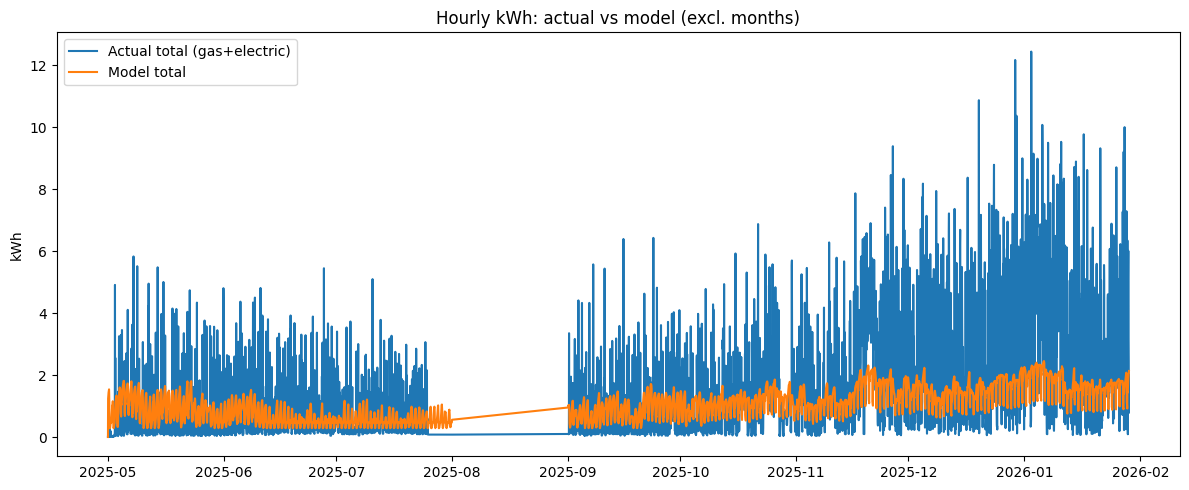

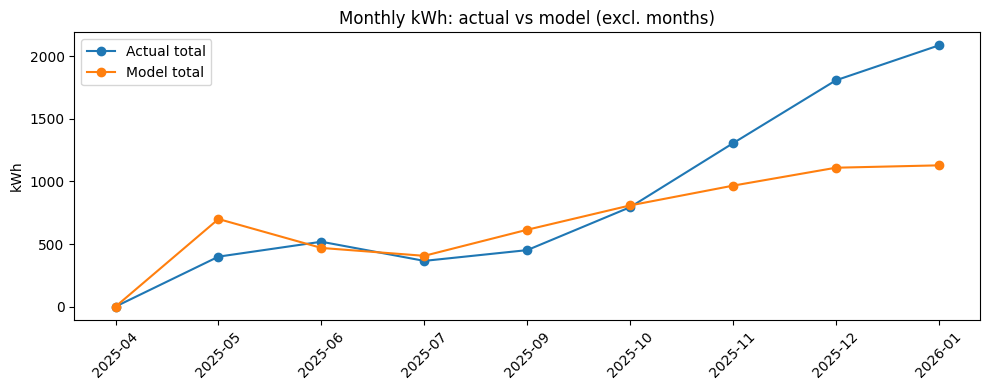

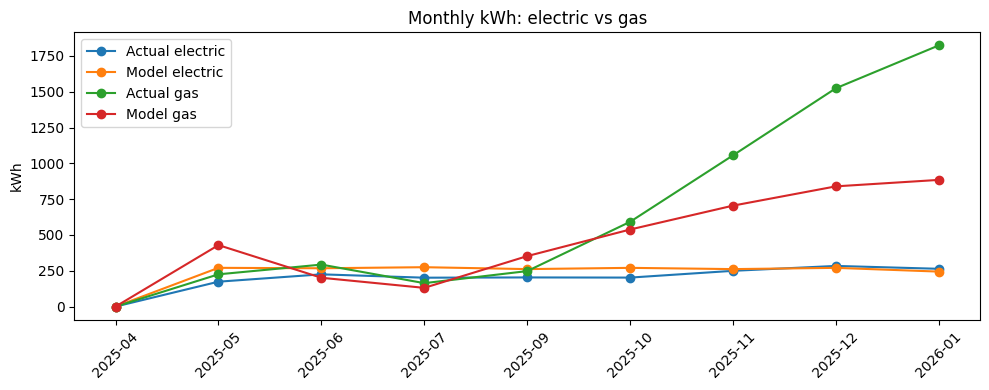

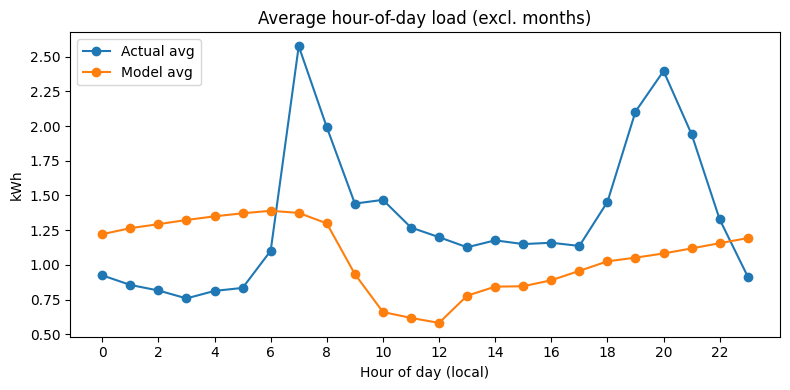

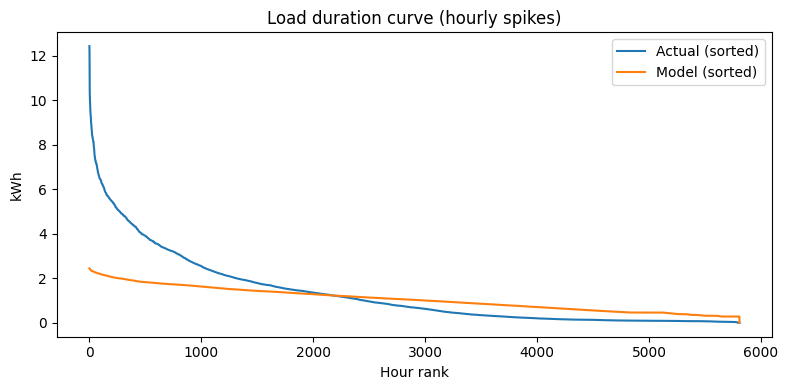

In [14]:
# ---- Plots ----

import matplotlib.pyplot as plt

# Hourly time series (excluded months removed)
plt.figure(figsize=(12, 5))
plt.plot(compare_excl["timestamp"], compare_excl["actual_total_kwh"], label="Actual total (gas+electric)")
plt.plot(compare_excl["timestamp"], compare_excl["model_total_kwh"], label="Model total")
plt.title("Hourly kWh: actual vs model (excl. months)")
plt.ylabel("kWh")
plt.legend()
plt.tight_layout()

# Monthly totals (overall)
plt.figure(figsize=(10, 4))
plt.plot(monthly["month"].astype(str), monthly["actual_total_kwh"], marker="o", label="Actual total")
plt.plot(monthly["month"].astype(str), monthly["model_total_kwh"], marker="o", label="Model total")
plt.title("Monthly kWh: actual vs model (excl. months)")
plt.ylabel("kWh")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Monthly fuel split comparison
plt.figure(figsize=(10, 4))
plt.plot(monthly["month"].astype(str), monthly["electric_kwh"], marker="o", label="Actual electric")
plt.plot(monthly["month"].astype(str), monthly["model_electric_kwh"], marker="o", label="Model electric")
plt.plot(monthly["month"].astype(str), monthly["gas_kwh"], marker="o", label="Actual gas")
plt.plot(monthly["month"].astype(str), monthly["model_gas_kwh"], marker="o", label="Model gas")
plt.title("Monthly kWh: electric vs gas")
plt.ylabel("kWh")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Hour-of-day profile (to compare schedule-driven shape)
local = compare_excl.copy()
local["local_hour"] = local["timestamp"].dt.tz_convert("Europe/London").dt.hour
profile = local.groupby("local_hour", as_index=False).agg(
    actual_total_kwh=("actual_total_kwh", "mean"),
    model_total_kwh=("model_total_kwh", "mean"),
)

plt.figure(figsize=(8, 4))
plt.plot(profile["local_hour"], profile["actual_total_kwh"], marker="o", label="Actual avg")
plt.plot(profile["local_hour"], profile["model_total_kwh"], marker="o", label="Model avg")
plt.title("Average hour-of-day load (excl. months)")
plt.xlabel("Hour of day (local)")
plt.ylabel("kWh")
plt.xticks(range(0,24,2))
plt.legend()
plt.tight_layout()

# Load duration curve (hourly spikes)
plt.figure(figsize=(8, 4))
plt.plot(
    np.sort(compare_excl["actual_total_kwh"].values)[::-1],
    label="Actual (sorted)"
)
plt.plot(
    np.sort(compare_excl["model_total_kwh"].values)[::-1],
    label="Model (sorted)"
)
plt.title("Load duration curve (hourly spikes)")
plt.xlabel("Hour rank")
plt.ylabel("kWh")
plt.legend()
plt.tight_layout()


## Calibration diagnostics

We use multiple signals to separate mechanisms:

- **Temperature sensitivity** (seasonality): slope of kWh vs heating degree hours (HDH).
- **Daily schedule shape**: correlation between average hour‑of‑day profiles.
- **Winter/summer ratio**: ratio of total kWh in winter months vs summer months.
- **Peak load error**: error between 99th‑percentile hourly kWh.

These metrics are used both for reporting and to score grid‑search results.


In [15]:
# ---- Diagnostics (temp sensitivity, schedules, seasonality, peaks) ----

# Build a simple HDH series from climate (aligned window)
# HDH = max(0, setpoint - temp) per hour
setpoint = float(getattr(model, "heating_setpoint_C", 18.5))
cf = ClimateField(str(CLIMATE_PARQUET))

# Extract climate temps for the simulated period (aligned)
idx0 = cf.time_index_for(start_utc_aligned)
idx1 = idx0 + num_hours
if idx1 > len(cf.times):
    idx1 = len(cf.times)

# Map target UPRN to climate point via model mapping
# Use the first household's clim_idx (only UPRN if RUN_ONLY_TARGET)
if RUN_ONLY_TARGET:
    h0 = model.household_agents[0]
else:
    h0 = next(h for h in model.household_agents if str(h.unique_id) == TARGET_UPRN)

clim_idx = getattr(h0, "clim_idx", None)
if clim_idx is None:
    raise ValueError("Household climate index not set; check geometry/climate mapping.")

temps = cf.temps[idx0:idx1, clim_idx]
clim_times = pd.to_datetime(cf.times[idx0:idx1], utc=True)

clim = pd.DataFrame({"timestamp": clim_times, "temp_C": temps})
clim["hdh"] = np.maximum(0.0, setpoint - clim["temp_C"])

# Merge with compare_excl (actual vs model)
_diag = compare_excl.merge(clim, on="timestamp", how="left")

# Temperature sensitivity (kWh per HDH): simple linear slope
# Avoid divide-by-zero for all‑zero HDH (summer)
if _diag["hdh"].sum() > 0:
    slope_actual = (_diag["actual_total_kwh"] * _diag["hdh"]).sum() / (_diag["hdh"]**2).sum()
    slope_model = (_diag["model_total_kwh"] * _diag["hdh"]).sum() / (_diag["hdh"]**2).sum()
else:
    slope_actual = np.nan
    slope_model = np.nan

# Hour‑of‑day profile correlation (schedule shape)
local = _diag.copy()
local["local_hour"] = local["timestamp"].dt.tz_convert("Europe/London").dt.hour
prof = local.groupby("local_hour", as_index=False).agg(
    actual_total_kwh=("actual_total_kwh", "mean"),
    model_total_kwh=("model_total_kwh", "mean"),
)
if prof["actual_total_kwh"].std() == 0 or prof["model_total_kwh"].std() == 0:
    hod_corr = np.nan
else:
    hod_corr = np.corrcoef(prof["actual_total_kwh"], prof["model_total_kwh"])[0,1]

# Winter/summer ratio (customize months if needed)
WINTER_MONTHS = {"11", "12", "01", "02"}
SUMMER_MONTHS = {"06", "07"}

local["month_num"] = local["timestamp"].dt.month.astype(str).str.zfill(2)

winter_actual = local[local["month_num"].isin(WINTER_MONTHS)]["actual_total_kwh"].sum()
winter_model  = local[local["month_num"].isin(WINTER_MONTHS)]["model_total_kwh"].sum()

summer_actual = local[local["month_num"].isin(SUMMER_MONTHS)]["actual_total_kwh"].sum()
summer_model  = local[local["month_num"].isin(SUMMER_MONTHS)]["model_total_kwh"].sum()

winter_summer_ratio_actual = winter_actual / summer_actual if summer_actual > 0 else np.nan
winter_summer_ratio_model  = winter_model  / summer_model  if summer_model  > 0 else np.nan

# Peak load error (99th percentile)
peak_actual = np.percentile(local["actual_total_kwh"], 99)
peak_model  = np.percentile(local["model_total_kwh"], 99)
peak_error = peak_model - peak_actual

pd.DataFrame([{
    "temp_slope_actual": slope_actual,
    "temp_slope_model": slope_model,
    "hour_profile_corr": hod_corr,
    "winter_summer_ratio_actual": winter_summer_ratio_actual,
    "winter_summer_ratio_model": winter_summer_ratio_model,
    "peak_99_actual": peak_actual,
    "peak_99_model": peak_model,
    "peak_99_error": peak_error,
}])


,temp_slope_actual,temp_slope_model,hour_profile_corr,winter_summer_ratio_actual,winter_summer_ratio_model,peak_99_actual,peak_99_model,peak_99_error
0,0.176287,0.126292,-0.023941,5.888035,3.665922,7.199936,2.258492,-4.941444


In [18]:
# ---- Grid search tuning (optional; can be slow) ----

import yaml
from tempfile import NamedTemporaryFile

RUN_GRID_SEARCH = True
N_JOBS = 4  # set to 1 for sequential

# Expanded grid (single UPRN; adjust as needed)
GRID = {
    "heating_slope_kWh_per_deg": [0.10, 0.12, 0.14, 0.16],
    "heating_setpoint_C": [19.0, 20.0, 21.0],
    "baseline_anchor_kwh_per_hour": [0.15, 0.20, 0.25],
    "energy_per_person_home": [0.06, 0.10, 0.14],
    # Heating-only fuel multipliers
    "model_electric_heat_mult": [0.8, 1.0, 1.2],
    "model_gas_heat_mult": [1.0, 1.3, 1.6],
    # Spike intensity to mimic morning routines
    "spike_mult": [1.0, 1.5, 2.0],
    "gas_spike_share": [0.1, 0.3, 0.5],
}

# Precompute actual monthly totals (excluding months)
if "EXCLUDE_MONTHS" not in globals():
    EXCLUDE_MONTHS = set()

_actual = actual.copy()
_actual["month"] = _actual["timestamp"].dt.to_period("M")
_actual = _actual[~_actual["month"].astype(str).isin(EXCLUDE_MONTHS)].copy()

actual_monthly = _actual.groupby("month", as_index=False).agg(
    actual_total_kwh=("actual_total_kwh", "sum"),
    actual_electric_kwh=("electric_kwh", "sum"),
    actual_gas_kwh=("gas_kwh", "sum"),
)

# Helper: run model with an override and return diagnostics

def _run_model_with_overrides(overrides: dict, heat_mult_e: float, heat_mult_g: float, spike_mult: float, gas_spike_share: float):
    override_cfg = {
        "meta": {
            "name": "wf_uprn_grid",
            "date": "2026-02-05",
            "notes": f"grid overrides: {overrides}",
        },
        "model": overrides,
    }

    with NamedTemporaryFile(mode="w", suffix=".yaml", delete=True) as tf:
        yaml.safe_dump(override_cfg, tf)
        tf.flush()

        m = EnergyModel(
            gdf=lsoa_gdf,
            climate_parquet=str(CLIMATE_PARQUET),
            climate_start=start_utc_aligned,
            local_tz=LOCAL_TZ,
            collect_agent_level=True,
            agent_collect_every=1,
            config_path=tf.name,
        )
        for _ in range(num_hours):
            m.step()

        agent_df = m.agent_dc.get_agent_vars_dataframe().reset_index()
        hh = agent_df[(agent_df["agent_type"] == "household") & (agent_df["AgentID"].astype(str) == TARGET_UPRN)].copy()
        hh["timestamp"] = start_utc_aligned + pd.to_timedelta(hh["Step"], unit="h")
        sim = hh[["timestamp", "base_kwh", "heat_kwh", "spike_kwh", "climate_cooling_kWh", "other_kwh", "is_gas", "is_electric_heating", "main_fuel_type", "main_heating_system"]].copy()

        # Align to actual window + excluded months
        sim = sim[(sim["timestamp"] >= start_utc_aligned) & (sim["timestamp"] < end_utc_aligned)].copy()
        sim["month"] = sim["timestamp"].dt.to_period("M")
        sim = sim[~sim["month"].astype(str).isin(EXCLUDE_MONTHS)].copy()

        sim["spike_kwh"] = sim["spike_kwh"] * spike_mult

        fuel = (sim["main_fuel_type"].iloc[0] or "").lower() if len(sim) else ""
        heat = (sim["main_heating_system"].iloc[0] or "").lower() if len(sim) else ""
        if (sim["is_electric_heating"].iloc[0] if len(sim) else 0) == 1 or "electric" in fuel:
            heating_fuel = "electric"
        elif (sim["is_gas"].iloc[0] if len(sim) else 0) == 1 or "gas" in fuel or "boiler" in heat:
            heating_fuel = "gas"
        else:
            heating_fuel = "other"

        if heating_fuel == "gas":
            model_gas_heat = sim["heat_kwh"] * heat_mult_g
            model_electric_heat = 0.0
            model_gas_spike = sim["spike_kwh"] * gas_spike_share
            model_electric_spike = sim["spike_kwh"] * (1.0 - gas_spike_share)
        elif heating_fuel == "electric":
            model_gas_heat = 0.0
            model_electric_heat = sim["heat_kwh"] * heat_mult_e
            model_gas_spike = 0.0
            model_electric_spike = sim["spike_kwh"]
        else:
            model_gas_heat = 0.0
            model_electric_heat = 0.0
            model_gas_spike = 0.0
            model_electric_spike = sim["spike_kwh"]

        sim["model_electric_kwh"] = sim["base_kwh"] + model_electric_spike + sim["climate_cooling_kWh"] + model_electric_heat
        sim["model_gas_kwh"] = model_gas_heat + model_gas_spike
        sim["model_total_kwh"] = sim["model_electric_kwh"] + sim["model_gas_kwh"] + sim["other_kwh"]

        model_monthly = sim.groupby("month", as_index=False).agg(
            model_total_kwh=("model_total_kwh", "sum"),
            model_electric_kwh=("model_electric_kwh", "sum"),
            model_gas_kwh=("model_gas_kwh", "sum"),
        )

        merged = actual_monthly.merge(model_monthly, on="month", how="inner")

        # Monthly RMSEs
        rmse_total = np.sqrt(np.mean((merged["model_total_kwh"] - merged["actual_total_kwh"]) ** 2))
        rmse_e = np.sqrt(np.mean((merged["model_electric_kwh"] - merged["actual_electric_kwh"]) ** 2))
        rmse_g = np.sqrt(np.mean((merged["model_gas_kwh"] - merged["actual_gas_kwh"]) ** 2))

        # Diagnostics: temp slope, hour‑profile corr, winter/summer ratio, peak error
        sim_hr = sim[["timestamp", "model_total_kwh"]].copy()
        sim_hr = sim_hr.merge(clim, on="timestamp", how="left")

        if sim_hr["hdh"].sum() > 0:
            slope_model = (sim_hr["model_total_kwh"] * sim_hr["hdh"]).sum() / (sim_hr["hdh"]**2).sum()
        else:
            slope_model = np.nan

        # Use precomputed diagnostics from actual+model (from earlier cell)
        slope_actual = slope_actual_global

        # Hour-of-day correlation
        tmp = sim_hr.copy()
        tmp["local_hour"] = tmp["timestamp"].dt.tz_convert("Europe/London").dt.hour
        prof = tmp.groupby("local_hour", as_index=False).agg(model_total_kwh=("model_total_kwh", "mean"))
        hod_corr = np.nan
        if prof["model_total_kwh"].std() > 0:
            hod_corr = np.corrcoef(prof["model_total_kwh"], hod_profile_actual)[0,1]

        # Winter/summer ratio
        tmp["month_num"] = tmp["timestamp"].dt.month.astype(str).str.zfill(2)
        winter_model = tmp[tmp["month_num"].isin(WINTER_MONTHS)]["model_total_kwh"].sum()
        summer_model = tmp[tmp["month_num"].isin(SUMMER_MONTHS)]["model_total_kwh"].sum()
        winter_summer_ratio_model = winter_model / summer_model if summer_model > 0 else np.nan

        # Peak error
        peak_model = np.percentile(tmp["model_total_kwh"], 99)

        # Composite score (weights can be tuned)
        score = (
            rmse_total
            + 0.5 * (rmse_e + rmse_g)
            + 0.25 * abs(slope_model - slope_actual)
            + 0.25 * abs(winter_summer_ratio_model - winter_summer_ratio_actual)
            + 0.1 * abs(peak_model - peak_actual)
            + (0.5 * (1 - hod_corr) if not np.isnan(hod_corr) else 0.0)
        )

        return {
            "rmse_total": rmse_total,
            "rmse_electric": rmse_e,
            "rmse_gas": rmse_g,
            "temp_slope_model": slope_model,
            "hour_profile_corr": hod_corr,
            "winter_summer_ratio_model": winter_summer_ratio_model,
            "peak_99_model": peak_model,
            "score": score,
        }


# Precompute actual slope + profile for scoring
if _diag["hdh"].sum() > 0:
    slope_actual_global = (_diag["actual_total_kwh"] * _diag["hdh"]).sum() / (_diag["hdh"]**2).sum()
else:
    slope_actual_global = np.nan

prof_actual = local.groupby("local_hour", as_index=False).agg(actual_total_kwh=("actual_total_kwh", "mean"))
hod_profile_actual = prof_actual["actual_total_kwh"].values

# Build parameter grid
param_grid = []
for slope in GRID["heating_slope_kWh_per_deg"]:
    for setpoint in GRID["heating_setpoint_C"]:
        for base in GRID["baseline_anchor_kwh_per_hour"]:
            for eph in GRID["energy_per_person_home"]:
                for mult_e in GRID["model_electric_heat_mult"]:
                    for mult_g in GRID["model_gas_heat_mult"]:
                        for spike_mult in GRID["spike_mult"]:
                            for gas_spike_share in GRID["gas_spike_share"]:
                                param_grid.append((
                                {
                                    "heating_slope_kWh_per_deg": slope,
                                    "heating_setpoint_C": setpoint,
                                    "baseline_anchor_kwh_per_hour": base,
                                    "energy_per_person_home": eph,
                                    # Remove caps by setting high values
                                    "max_heat_kwh_per_hour": 200.0,
                                    "max_total_kwh_per_hour": 200.0,
                                },
                                mult_e,
                                mult_g,
                                spike_mult,
                                gas_spike_share,
                            ))


def _evaluate_param(args):
    overrides, mult_e, mult_g, spike_mult, gas_spike_share = args
    metrics = _run_model_with_overrides(overrides, mult_e, mult_g, spike_mult, gas_spike_share)
    return {
        "slope": overrides["heating_slope_kWh_per_deg"],
        "setpoint": overrides["heating_setpoint_C"],
        "baseline": overrides["baseline_anchor_kwh_per_hour"],
        "energy_per_person_home": overrides["energy_per_person_home"],
        "mult_electric_heat": mult_e,
        "mult_gas_heat": mult_g,
        "spike_mult": spike_mult,
        "gas_spike_share": gas_spike_share,
        **metrics,
    }

results = []

if RUN_GRID_SEARCH:
    # Try joblib parallelism if available; fallback to sequential
    try:
        from joblib import Parallel, delayed
        if N_JOBS > 1:
            results = Parallel(n_jobs=N_JOBS, verbose=5)(delayed(_evaluate_param)(p) for p in param_grid)
        else:
            results = [_evaluate_param(p) for p in param_grid]
    except Exception as e:
        print("Parallel backend unavailable, running sequential. Error:", e)
        results = [_evaluate_param(p) for p in param_grid]

    grid_df = pd.DataFrame(results).sort_values(["score", "rmse_total"]).reset_index(drop=True)
    grid_df.head(10)

    # Save full grid search results (timestamped)
    ts = pd.Timestamp.utcnow().strftime("%Y%m%d_%H%M%S")
    grid_results_path = Path(f"../results/wf_uprn_grid_search_{ts}.csv").resolve()
    grid_results_path.parent.mkdir(parents=True, exist_ok=True)
    grid_df.to_csv(grid_results_path, index=False)
    print("Saved grid search results to", grid_results_path)


/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/3082960340.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  _actual["month"] = _actual["timestamp"].dt.to_period("M")
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/3082960340.py:72: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/3082960340.py:72: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/3082960340.py:72: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/3082960340.py:72: UserWarning: Converting to PeriodArray/Index representation will drop timezone informat

Saved grid search results to /Users/abeltran/Documents/GitHub/spdt_abm/results/wf_uprn_grid_search_20260210_113257.csv


Best overrides: {'heating_slope_kWh_per_deg': 0.1, 'heating_setpoint_C': 19.0, 'baseline_anchor_kwh_per_hour': 0.15, 'energy_per_person_home': 0.06, 'max_heat_kwh_per_hour': 200.0, 'max_total_kwh_per_hour': 200.0}
Best heat multipliers: {'electric': 0.8, 'gas': 1.6}
Best spike mult: 1.0
Best gas spike share: 0.3


/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/3339495663.py:81: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sim["month"] = sim["timestamp"].dt.to_period("M")
/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/3339495663.py:133: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  actual_hr = actual_hr[~actual_hr["timestamp"].dt.to_period("M").astype(str).isin(EXCLUDE_MONTHS)]
/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_4404/3339495663.py:134: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sim_hr = sim_hr[~sim_hr["timestamp"].dt.to_period("M").astype(str).isin(EXCLUDE_MONTHS)]


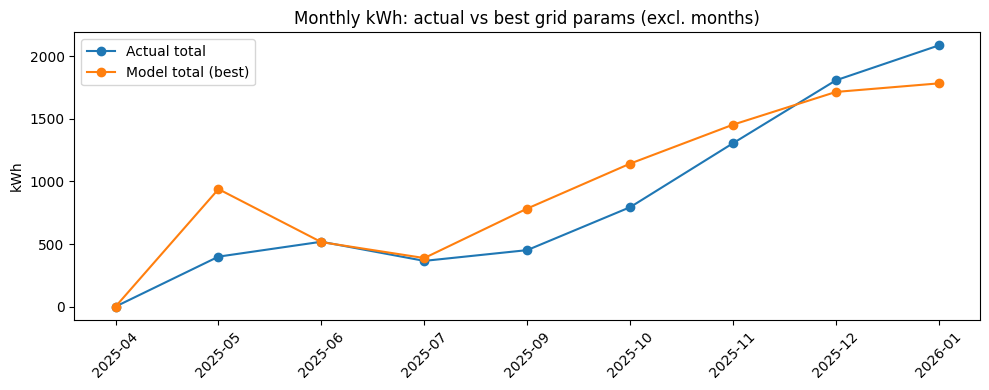

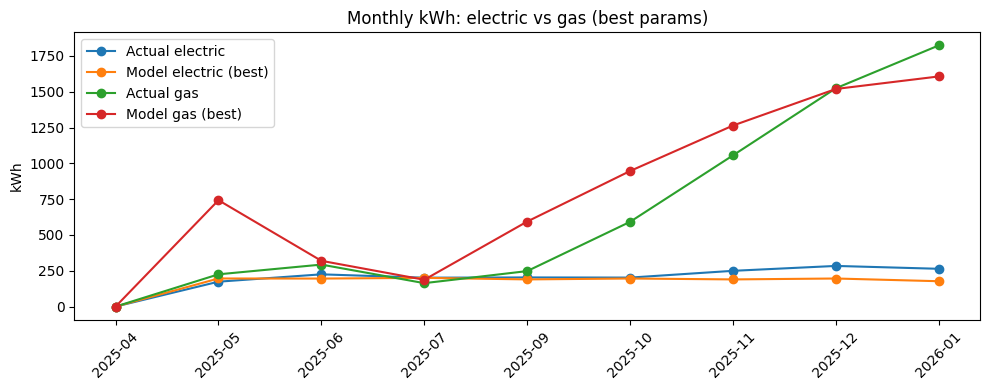

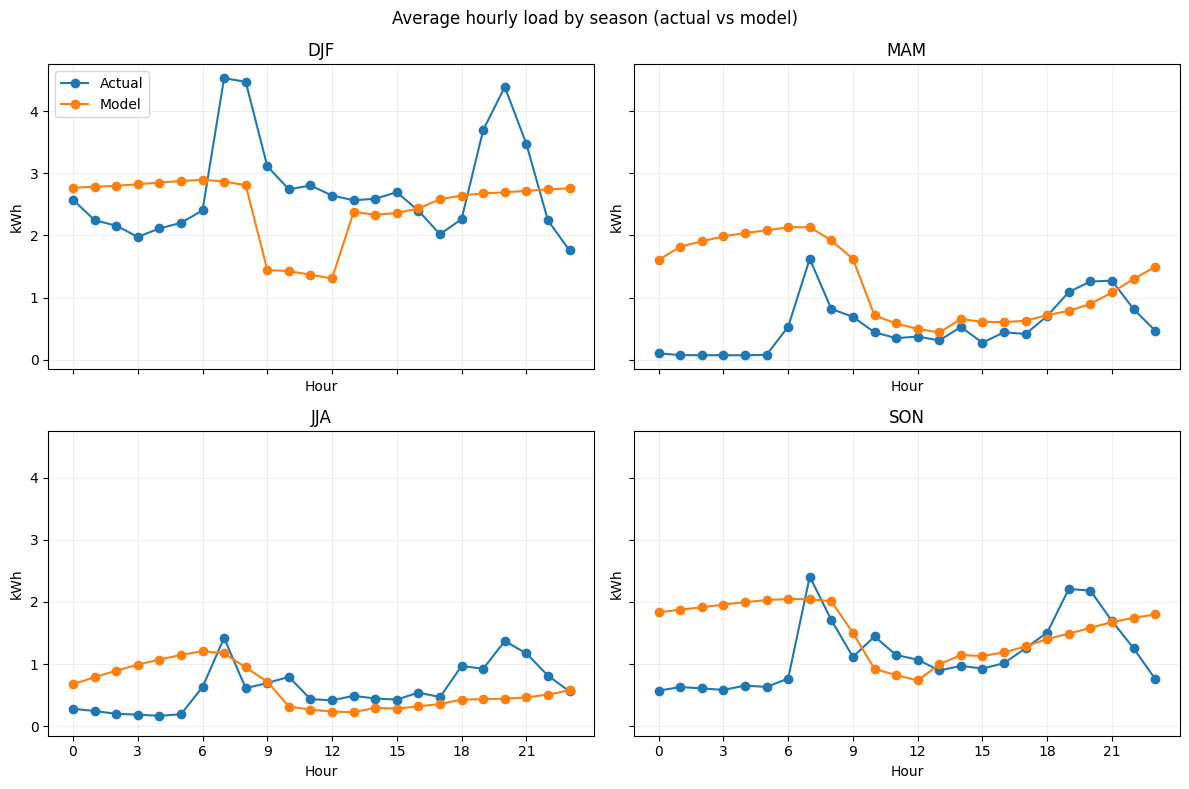

In [19]:
# ---- Rerun with best grid params and plot ----

if RUN_GRID_SEARCH:
    best = grid_df.iloc[0].to_dict()
    best_overrides = {
        "heating_slope_kWh_per_deg": float(best["slope"]),
        "heating_setpoint_C": float(best["setpoint"]),
        "baseline_anchor_kwh_per_hour": float(best["baseline"]),
        "energy_per_person_home": float(best["energy_per_person_home"]),
        "max_heat_kwh_per_hour": 200.0,
        "max_total_kwh_per_hour": 200.0,
    }
    best_mult_e = float(best["mult_electric_heat"])
    best_mult_g = float(best["mult_gas_heat"])
    best_spike_mult = float(best["spike_mult"])
    best_gas_spike_share = float(best["gas_spike_share"])
    print("Best overrides:", best_overrides)
    print("Best heat multipliers:", {"electric": best_mult_e, "gas": best_mult_g})
    print("Best spike mult:", best_spike_mult)
    print("Best gas spike share:", best_gas_spike_share)

    # Rerun to get hourly series for season plots
    override_cfg = {
        "meta": {"name": "wf_uprn_best", "date": "2026-02-05"},
        "model": best_overrides,
    }
    with NamedTemporaryFile(mode="w", suffix=".yaml", delete=True) as tf:
        yaml.safe_dump(override_cfg, tf)
        tf.flush()

        m = EnergyModel(
            gdf=lsoa_gdf,
            climate_parquet=str(CLIMATE_PARQUET),
            climate_start=start_utc_aligned,
            local_tz=LOCAL_TZ,
            collect_agent_level=True,
            agent_collect_every=1,
            config_path=tf.name,
        )
        for _ in range(num_hours):
            m.step()

        agent_df = m.agent_dc.get_agent_vars_dataframe().reset_index()
        hh = agent_df[(agent_df["agent_type"] == "household") & (agent_df["AgentID"].astype(str) == TARGET_UPRN)].copy()
        hh["timestamp"] = start_utc_aligned + pd.to_timedelta(hh["Step"], unit="h")
        sim = hh[["timestamp", "base_kwh", "heat_kwh", "spike_kwh", "climate_cooling_kWh", "other_kwh", "is_gas", "is_electric_heating", "main_fuel_type", "main_heating_system"]].copy()

        sim["spike_kwh"] = sim["spike_kwh"] * best_spike_mult

        fuel = (sim["main_fuel_type"].iloc[0] or "").lower() if len(sim) else ""
        heat = (sim["main_heating_system"].iloc[0] or "").lower() if len(sim) else ""
        if (sim["is_electric_heating"].iloc[0] if len(sim) else 0) == 1 or "electric" in fuel:
            heating_fuel = "electric"
        elif (sim["is_gas"].iloc[0] if len(sim) else 0) == 1 or "gas" in fuel or "boiler" in heat:
            heating_fuel = "gas"
        else:
            heating_fuel = "other"

        if heating_fuel == "gas":
            model_gas_heat = sim["heat_kwh"] * best_mult_g
            model_electric_heat = 0.0
            model_gas_spike = sim["spike_kwh"] * best_gas_spike_share
            model_electric_spike = sim["spike_kwh"] * (1.0 - best_gas_spike_share)
        elif heating_fuel == "electric":
            model_gas_heat = 0.0
            model_electric_heat = sim["heat_kwh"] * best_mult_e
            model_gas_spike = 0.0
            model_electric_spike = sim["spike_kwh"]
        else:
            model_gas_heat = 0.0
            model_electric_heat = 0.0
            model_gas_spike = 0.0
            model_electric_spike = sim["spike_kwh"]

        sim["model_electric_kwh"] = sim["base_kwh"] + model_electric_spike + sim["climate_cooling_kWh"] + model_electric_heat
        sim["model_gas_kwh"] = model_gas_heat + model_gas_spike
        sim["model_total_kwh"] = sim["model_electric_kwh"] + sim["model_gas_kwh"] + sim["other_kwh"]

    # Align to actual window + excluded months
    sim = sim[(sim["timestamp"] >= start_utc_aligned) & (sim["timestamp"] < end_utc_aligned)].copy()
    sim["month"] = sim["timestamp"].dt.to_period("M")
    sim = sim[~sim["month"].astype(str).isin(EXCLUDE_MONTHS)].copy()

    merged = actual_monthly.merge(
        sim.groupby("month", as_index=False).agg(
            model_total_kwh=("model_total_kwh", "sum"),
            model_electric_kwh=("model_electric_kwh", "sum"),
            model_gas_kwh=("model_gas_kwh", "sum"),
        ),
        on="month", how="inner"
    ).sort_values("month")

    plt.figure(figsize=(10, 4))
    plt.plot(merged["month"].astype(str), merged["actual_total_kwh"], marker="o", label="Actual total")
    plt.plot(merged["month"].astype(str), merged["model_total_kwh"], marker="o", label="Model total (best)")
    plt.title("Monthly kWh: actual vs best grid params (excl. months)")
    plt.ylabel("kWh")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()

    plt.figure(figsize=(10, 4))
    plt.plot(merged["month"].astype(str), merged["actual_electric_kwh"], marker="o", label="Actual electric")
    plt.plot(merged["month"].astype(str), merged["model_electric_kwh"], marker="o", label="Model electric (best)")
    plt.plot(merged["month"].astype(str), merged["actual_gas_kwh"], marker="o", label="Actual gas")
    plt.plot(merged["month"].astype(str), merged["model_gas_kwh"], marker="o", label="Model gas (best)")
    plt.title("Monthly kWh: electric vs gas (best params)")
    plt.ylabel("kWh")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()

    # ---- Seasonal hourly profiles ----
    def _season(m):
        if m in (12, 1, 2):
            return "DJF"
        if m in (3, 4, 5):
            return "MAM"
        if m in (6, 7, 8):
            return "JJA"
        return "SON"

    actual_hr = actual.copy()
    actual_hr["season"] = actual_hr["timestamp"].dt.month.map(_season)
    actual_hr["local_hour"] = actual_hr["timestamp"].dt.tz_convert("Europe/London").dt.hour

    sim_hr = sim.copy()
    sim_hr["season"] = sim_hr["timestamp"].dt.month.map(_season)
    sim_hr["local_hour"] = sim_hr["timestamp"].dt.tz_convert("Europe/London").dt.hour

    # Exclude months from seasonal profile too
    if EXCLUDE_MONTHS:
        actual_hr = actual_hr[~actual_hr["timestamp"].dt.to_period("M").astype(str).isin(EXCLUDE_MONTHS)]
        sim_hr = sim_hr[~sim_hr["timestamp"].dt.to_period("M").astype(str).isin(EXCLUDE_MONTHS)]

    prof_actual = actual_hr.groupby(["season", "local_hour"], as_index=False).agg(actual_kwh=("actual_total_kwh", "mean"))
    prof_model = sim_hr.groupby(["season", "local_hour"], as_index=False).agg(model_kwh=("model_total_kwh", "mean"))

    seasons = ["DJF", "MAM", "JJA", "SON"]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.ravel()
    for ax, s in zip(axes, seasons):
        a = prof_actual[prof_actual["season"] == s]
        b = prof_model[prof_model["season"] == s]
        ax.plot(a["local_hour"], a["actual_kwh"], marker="o", label="Actual")
        ax.plot(b["local_hour"], b["model_kwh"], marker="o", label="Model")
        ax.set_title(s)
        ax.set_xlabel("Hour")
        ax.set_ylabel("kWh")
        ax.set_xticks(range(0, 24, 3))
        ax.grid(alpha=0.2)
    axes[0].legend()
    plt.suptitle("Average hourly load by season (actual vs model)")
    plt.tight_layout()
